# Car Price Prediction — Oasis Infobyte SIP (Data Science, Task 3)

**Goal:** Predict the selling price of a used car based on its brand, model, age, mileage, fuel type, and other features.

**Dataset:** `cardekho_dataset.csv` (CarDekho Used Car Dataset, Kaggle).
Columns: `car_name`, `brand`, `model`, `vehicle_age`, `km_driven`, `seller_type`, `fuel_type`, `transmission_type`, `mileage`, `engine`, `max_power`, `seats`, `selling_price`.


## 1. Import libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")


## 2. Load the data

In [38]:
df = pd.read_csv("cardekho_dataset.csv")

# Drop the unnamed index column that comes with this CSV, if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [39]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


In [40]:
df.isnull().sum()


car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

## 3. Exploratory Data Analysis

Quick look at distributions and relationships before touching the model.


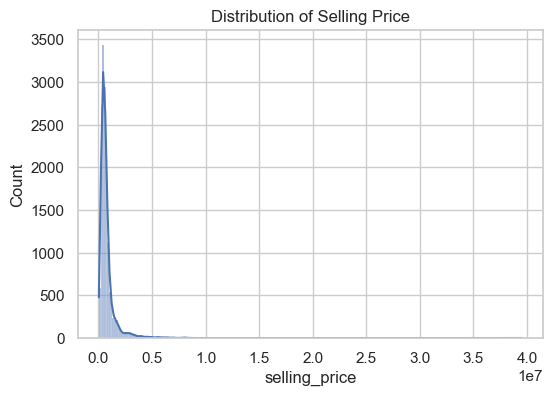

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(df['selling_price'], kde=True)
plt.title("Distribution of Selling Price")
plt.show()


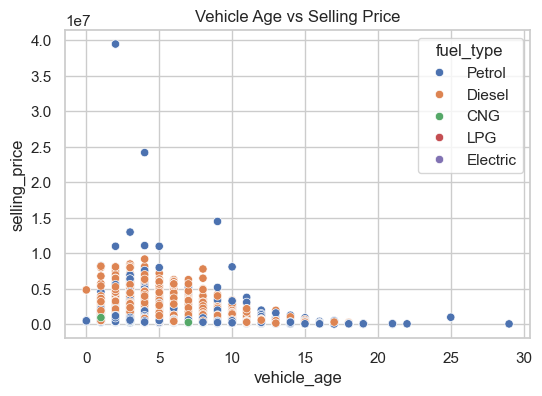

In [42]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='vehicle_age', y='selling_price', hue='fuel_type')
plt.title("Vehicle Age vs Selling Price")
plt.show()


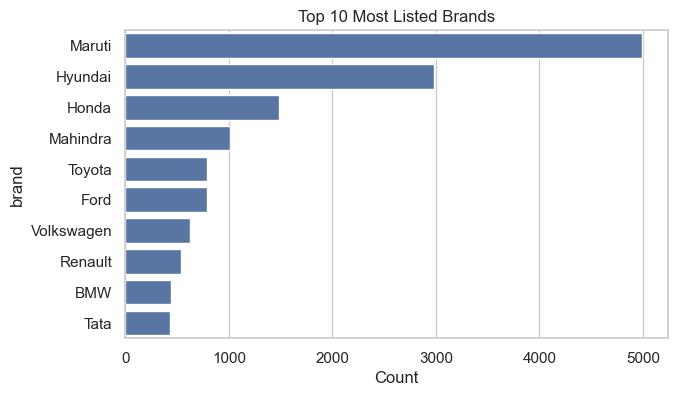

In [43]:
top_brands = df['brand'].value_counts().head(10)
plt.figure(figsize=(7,4))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top 10 Most Listed Brands")
plt.xlabel("Count")
plt.show()


## 4. Feature Engineering

- Drop `car_name` and `model` — too many unique values to encode usefully; `brand` already captures most of that signal.
- Encode categorical columns: `brand`, `seller_type`, `fuel_type`, `transmission_type`.


In [44]:
df.drop(columns=['car_name', 'model'], inplace=True)

cat_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,18,9,120000,1,4,1,19.70,796,46.30,5,120000
1,8,5,20000,1,4,1,18.90,1197,82.00,5,550000
2,8,11,60000,1,4,1,17.00,1197,80.00,5,215000
3,18,9,37000,1,4,1,20.92,998,67.10,5,226000
4,6,6,30000,0,1,1,22.77,1498,98.59,5,570000


## 5. Train / test split

In [45]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((12328, 10), (3083, 10))

## 6. Model training — Linear Regression (baseline)

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, lr_preds))
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))


Linear Regression
R2: 0.6638688531316196
MAE: 278522.27318113914
RMSE: 503024.26042563183


## 7. Model training — Random Forest (usually stronger)

In [47]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest")
print("R2:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))


Random Forest
R2: 0.9319007617122743
MAE: 102288.26213411143
RMSE: 226415.252420805


## 8. Feature importance (Random Forest)

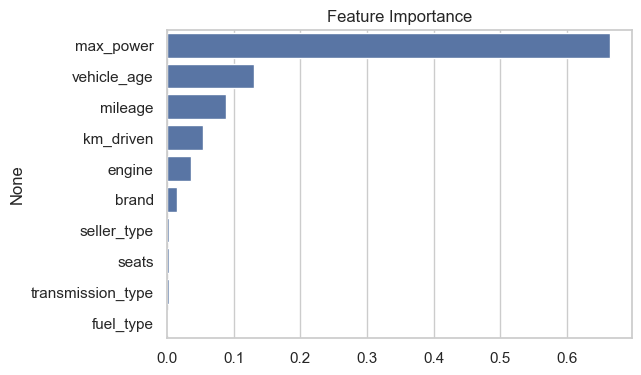

In [48]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance")
plt.show()


## 9. Conclusion

- Random Forest generally outperforms plain Linear Regression on this dataset because the relationship between features and price isn't purely linear.
- `max_power`, `vehicle_age`, and `engine` are typically the strongest predictors of `selling_price`.
- Next steps (optional): try Gradient Boosting / XGBoost, tune hyperparameters with GridSearchCV, or add cross-validation for a more robust score.
